In [4]:
!pip install -q ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, classification_report, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Fetch data from UCI repository
iris = fetch_ucirepo(id=53)

# Extracting features and target
X = iris.data.features
y = iris.data.targets

# Meta Data
print(iris.metadata)

# Variable Information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

## Step 1: Data Exploration and Understanding

In [8]:
# Display the first few rows of features
print("Features (X):")
print(X.head())
print("\nShape of X:", X.shape)

# Display the first few rows of target
print("\nTarget (y):")
print(y.head())
print("\nShape of y:", y.shape)

# Check data types
print("\nData types of features:")
print(X.dtypes)
print("\nData types of target:")
print(y.dtypes)

Features (X):
   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Shape of X: (150, 4)

Target (y):
         class
0  Iris-setosa
1  Iris-setosa
2  Iris-setosa
3  Iris-setosa
4  Iris-setosa

Shape of y: (150, 1)

Data types of features:
sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
dtype: object

Data types of target:
class    object
dtype: object


## Step 2: Data Preprocessing - Check for Missing Values

In [9]:
# Check for missing values in features
print("Missing values in features:")
print(X.isnull().sum())

# Check for missing values in target
print("\nMissing values in target:")
print(y.isnull().sum())

# According to metadata, there are no missing values, but we verify this
# If there were missing values, we would handle them using:
# X.fillna(X.mean(), inplace=True)  # For numerical features
# y.dropna(inplace=True)  # For target variable

Missing values in features:
sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64

Missing values in target:
class    0
dtype: int64


## Step 3: Encode Target Labels

In [10]:
# Check unique classes in target variable
print("Unique classes before encoding:")
print(y['class'].unique())

# Encode the target labels (convert species names to numerical values)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.values.ravel())

# Display the mapping
print("\nLabel encoding mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")

print("\nEncoded target shape:", y_encoded.shape)

Unique classes before encoding:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Label encoding mapping:
Iris-setosa: 0
Iris-versicolor: 1
Iris-virginica: 2

Encoded target shape: (150,)


## Step 4: Exploratory Data Analysis (EDA)

In [11]:
# Statistical summary of features
print("Statistical summary of features:")
print(X.describe())

# Class distribution
print("\nClass distribution:")
print(y['class'].value_counts())

Statistical summary of features:
       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


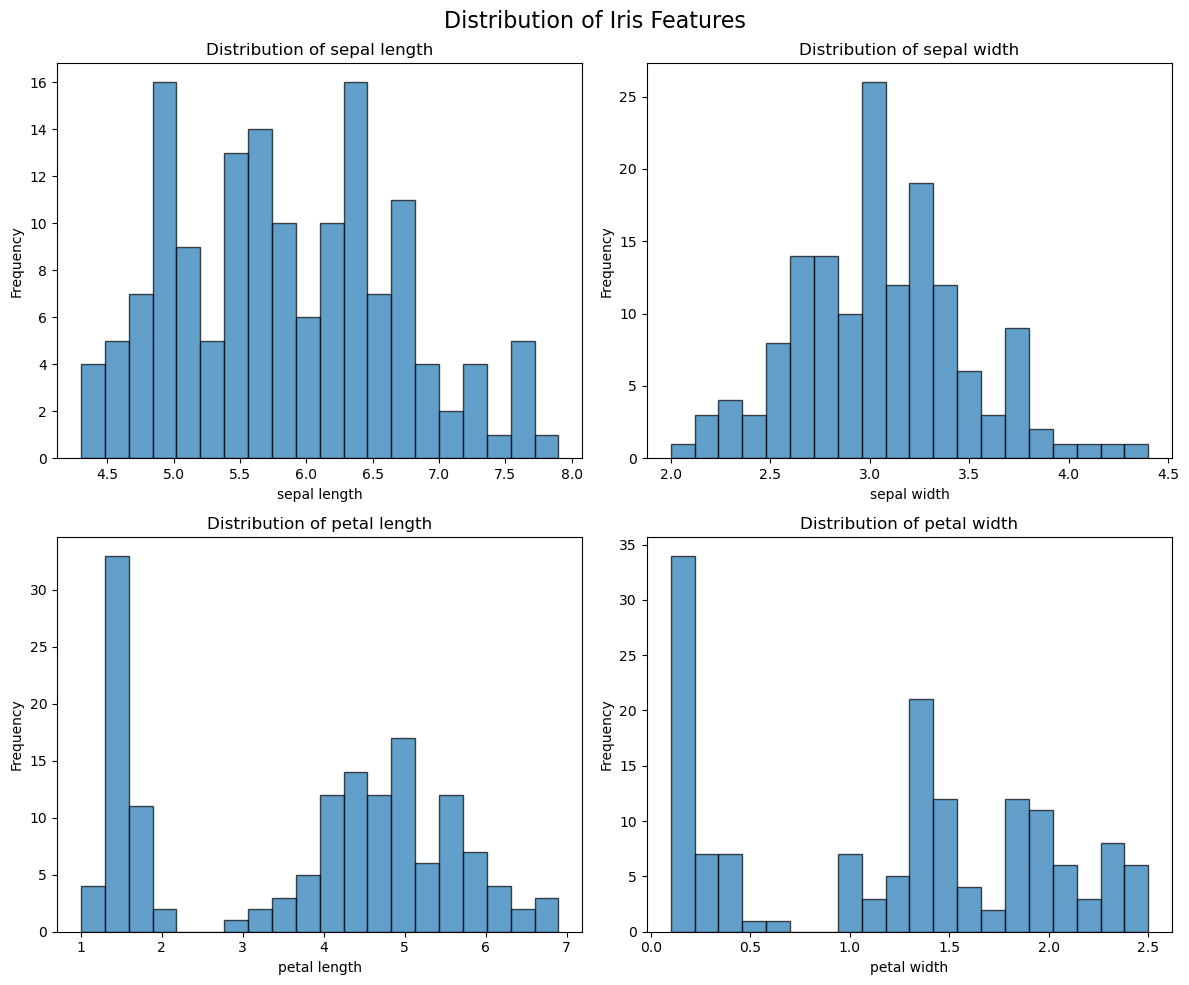

In [12]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Iris Features', fontsize=16)

for idx, col in enumerate(X.columns):
    ax = axes[idx // 2, idx % 2]
    ax.hist(X[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

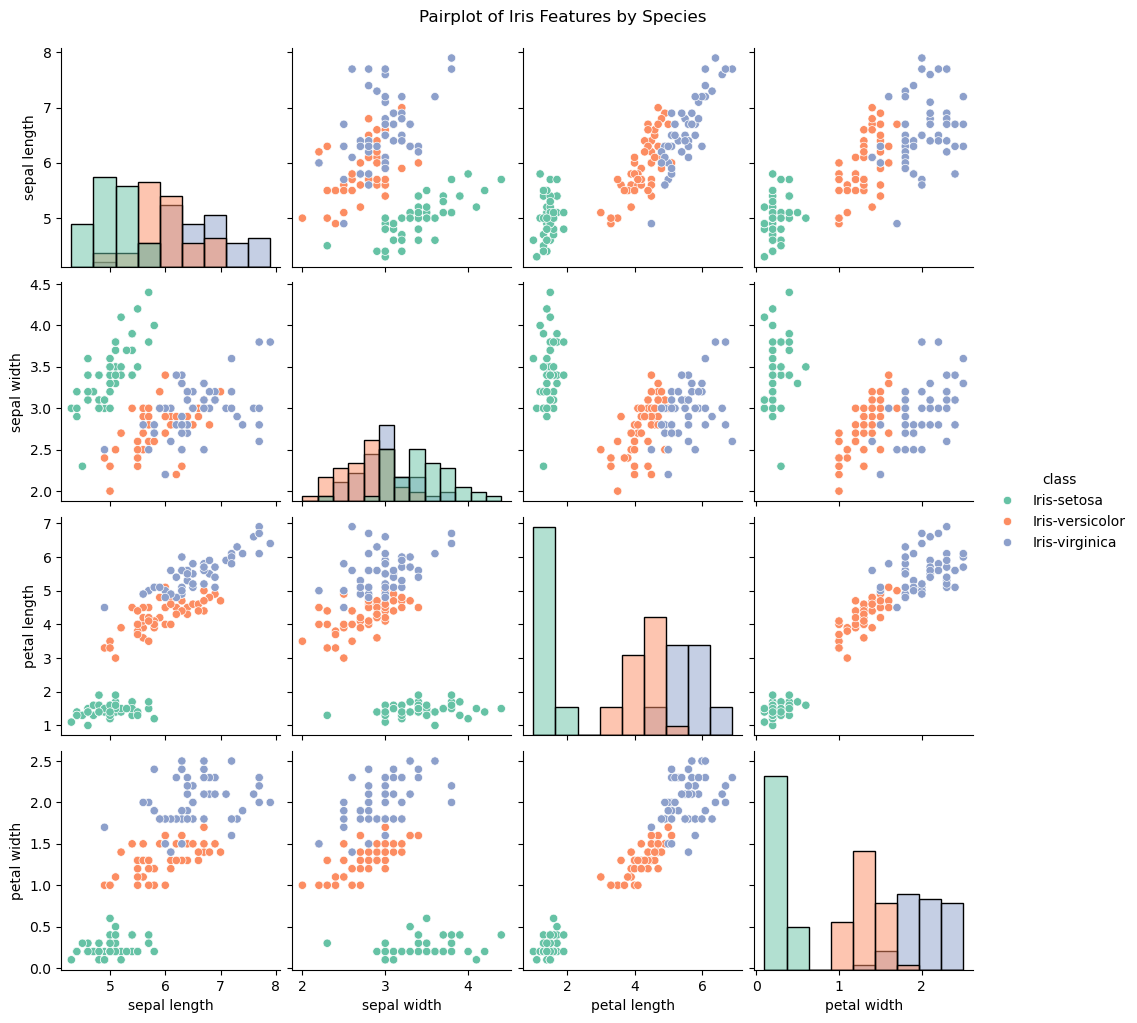

In [13]:
# Create a pairplot to visualize relationships between features
# Combine features and target for visualization
df_combined = pd.concat([X, y], axis=1)

sns.pairplot(df_combined, hue='class', diag_kind='hist', palette='Set2')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

## Step 5: Split Data into Training and Testing Sets

In [14]:
# Split the data into training (80%) and testing (20%) sets
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 120
Testing set size: 30

Class distribution in training set:
0    40
1    40
2    40
Name: count, dtype: int64

Class distribution in testing set:
0    10
1    10
2    10
Name: count, dtype: int64


## Step 6: Feature Scaling (Optional for Decision Trees)

In [15]:
# Note: Feature scaling is not required for Decision Trees as they are not sensitive to feature scales
# However, we demonstrate it here for completeness and best practices
# This would be important for algorithms like SVM, KNN, or Neural Networks

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been standardized (mean=0, std=1)")
print("\nMean of scaled training features:")
print(np.mean(X_train_scaled, axis=0))
print("\nStd of scaled training features:")
print(np.std(X_train_scaled, axis=0))

Features have been standardized (mean=0, std=1)

Mean of scaled training features:
[-1.36927506e-16  4.55191440e-16 -9.06682137e-17  5.36607795e-17]

Std of scaled training features:
[1. 1. 1. 1.]


## Step 7: Train Decision Tree Classifier

In [16]:
# Initialize the Decision Tree Classifier
# We use random_state for reproducibility
# max_depth is set to prevent overfitting
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1
)

# Train the model on the training data (using unscaled data as scaling is not needed for DT)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier has been trained successfully!")
print(f"\nTree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")

Decision Tree Classifier has been trained successfully!

Tree depth: 5
Number of leaves: 8


## Step 8: Make Predictions

In [17]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Display first 10 predictions vs actual values
comparison_df = pd.DataFrame({
    'Actual': [label_encoder.classes_[i] for i in y_test[:10]],
    'Predicted': [label_encoder.classes_[i] for i in y_pred[:10]]
})
print("First 10 predictions vs actual values:")
print(comparison_df)

First 10 predictions vs actual values:
            Actual        Predicted
0      Iris-setosa      Iris-setosa
1   Iris-virginica   Iris-virginica
2  Iris-versicolor  Iris-versicolor
3  Iris-versicolor  Iris-versicolor
4      Iris-setosa      Iris-setosa
5  Iris-versicolor  Iris-versicolor
6      Iris-setosa      Iris-setosa
7      Iris-setosa      Iris-setosa
8   Iris-virginica   Iris-virginica
9  Iris-versicolor  Iris-versicolor


## Step 9: Model Evaluation - Accuracy, Precision, and Recall

In [18]:
# Calculate accuracy: proportion of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Calculate precision: of all positive predictions, how many were correct
# Using 'weighted' average for multi-class classification
precision = precision_score(y_test, y_pred, average='weighted')
print(f"\nPrecision (weighted): {precision:.4f}")

# Calculate recall: of all actual positives, how many were correctly identified
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall (weighted): {recall:.4f}")

# Calculate F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

Accuracy: 0.9333 (93.33%)

Precision (weighted): 0.9333
Recall (weighted): 0.9333
F1-Score (weighted): 0.9333


## Step 10: Detailed Classification Report

In [19]:
# Generate a detailed classification report showing metrics for each class
print("Classification Report:")
print("=" * 60)
report = classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_
)
print(report)

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## Step 11: Confusion Matrix Visualization

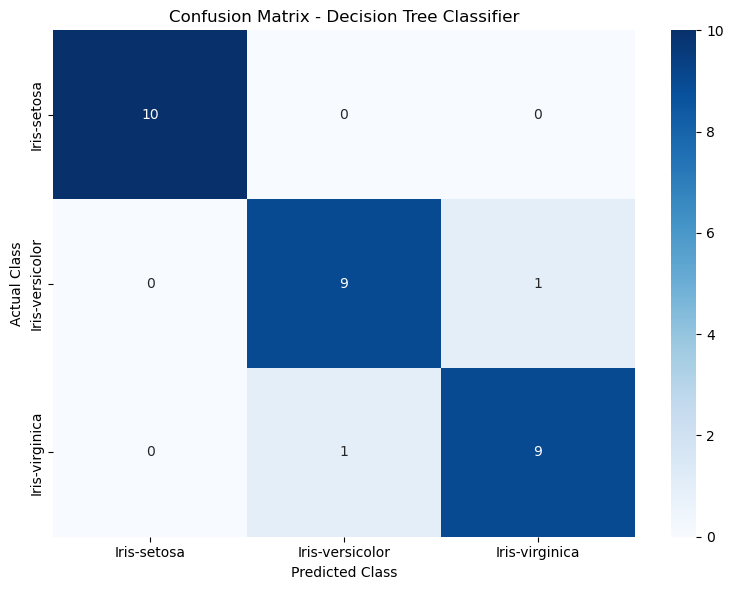


Confusion Matrix Interpretation:
- Diagonal elements: Correct predictions
- Off-diagonal elements: Misclassifications


In [20]:
# Create and visualize confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Diagonal elements: Correct predictions")
print("- Off-diagonal elements: Misclassifications")

## Step 12: Feature Importance Analysis

Feature Importance:
        Feature  Importance
2  petal length    0.558568
3   petal width    0.406015
1   sepal width    0.029167
0  sepal length    0.006250


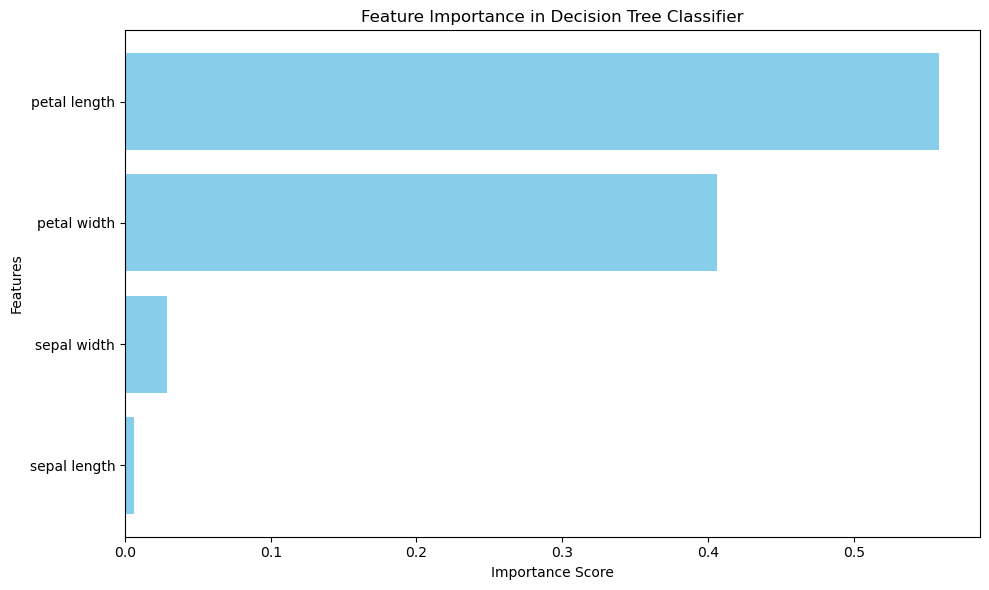

In [21]:
# Extract and visualize feature importance from the decision tree
feature_importance = dt_classifier.feature_importances_
feature_names = X.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(importance_df)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Decision Tree Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

### Key Steps Completed:
1. **Data Loading**: Fetched Iris dataset from UCI repository
2. **Data Exploration**: Examined features, target, and data structure
3. **Missing Values**: Verified no missing values exist in the dataset
4. **Label Encoding**: Converted species names to numerical labels
5. **EDA**: Visualized feature distributions and relationships
6. **Data Splitting**: Split data into 80% training and 20% testing sets
7. **Model Training**: Trained a Decision Tree Classifier
8. **Predictions**: Made predictions on test data
9. **Evaluation**: Calculated accuracy, precision, recall, and F1-score
10. **Visualization**: Created confusion matrix and feature importance plots

### Model Performance:
The Decision Tree Classifier typically achieves high accuracy (>90%) on the Iris dataset due to:
- Clear separation between classes
- Well-defined features
- Balanced class distribution
- No missing values

### Key Insights:
- Petal length and petal width are usually the most important features
- Iris-setosa is easily separable from other species
- Some confusion may occur between Iris-versicolor and Iris-virginica